# Onset-HFO 1 — Detecting ripples and spikes in real intracranial EEG

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/berdakh/bci-gan/blob/master/onset-hfo/notebooks/01_hfo_detection_quickstart.ipynb)

**What you will do in the next ten minutes.** Download one minute of a real
intracranial EEG recording from a public archive, filter it the way an
epileptologist's software would, run two classical high-frequency-oscillation
(HFO) detectors and one interictal-spike detector over it, look at what they
found, and produce a structured report that cites the exact signal windows
behind every number.

**Why this matters.** In epilepsy surgery the question is *which tissue is
generating the seizures*. Ripples (80–250 Hz oscillations lasting a few tens
of milliseconds) and interictal epileptiform discharges are two of the
markers used to answer it. Counting them by eye across 100 channels is
impossible, so detection is automated — and automated detectors are famously
easy to fool.

**What this is not.** Not a medical device, not validated, not a diagnosis.
It is a transparent first prototype whose numbers you can check.

**The vocabulary**, if any of it is new:

| term | meaning |
|---|---|
| iEEG / ECoG / SEEG | electrodes recording *inside* the skull: grids on the surface, depth electrodes in tissue |
| contact | one recording point on an electrode, e.g. `ATT3` |
| bipolar pair | the difference between two neighbouring contacts, e.g. `ATT3-ATT4` — the channel a detector actually sees |
| HFO / ripple | an 80–250 Hz oscillation of a few tens of milliseconds |
| IED / spike | an interictal epileptiform discharge: a sharp 20–70 ms transient |
| ictal / interictal | during a seizure / between seizures |
| SOZ | seizure onset zone — what clinicians try to find, and what this prototype does **not** claim to identify |

In [1]:
# Colab setup. On your own machine, skip this cell and run
#   pip install -e ".[dev]"  from the onset-hfo directory instead.
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO = "https://github.com/berdakh/bci-gan.git"
BRANCH = "master"   # the repository default branch

if IN_COLAB and not os.path.exists("bci-gan"):
    subprocess.run(["git", "clone", "-q", "--branch", BRANCH, "--depth", "1", REPO], check=True)
if IN_COLAB:
    os.chdir("/content/bci-gan/onset-hfo")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("working directory:", os.getcwd())

working directory: /home/user/bci-gan/onset-hfo


## 1. The data

[OpenNeuro **ds003029**](https://openneuro.org/datasets/ds003029) —
*Epilepsy-iEEG-Multicenter-Dataset*, CC0 licensed, four clinical centres,
100 subjects, BIDS format, with clinician markers for seizure onset and
offset.

We use subject `sub-pt01`, an ECoG recording sampled at 1000 Hz, and we take
**60 seconds** of it: 26 s before the marked electrographic onset and 34 s
after. The loader downloads only those seconds (~24 MB) by asking the archive
for a byte range of the binary file — the whole run is 105 MB and the whole
dataset is far larger.

One consequence of 1000 Hz sampling, stated up front: the Nyquist frequency
is 500 Hz, so **ripples (80–250 Hz) can be analysed and fast ripples
(250–500 Hz) cannot**. The pipeline refuses to pretend otherwise.

In [2]:
from onset_hfo.datasets import fetch_slice, list_runs

# What else is available for this subject (not downloaded, just listed):
print(list_runs("sub-pt01").to_string(index=False))

recording = fetch_slice(subject="sub-pt01", task="ictal", run="01",
                        t_start=50.0, t_stop=110.0)

 subject  task  acq run  size_mb
sub-pt01 ictal ecog  01    105.5
sub-pt01 ictal ecog  02    139.3
sub-pt01 ictal ecog  03    145.5
sub-pt01 ictal ecog  04    122.0
[onset-hfo] using cached slice /home/user/bci-gan/onset-hfo/artifacts/data/ds003029/sub-pt01_task-ictal_run-01_50-110s


[onset-hfo] loaded sub-pt01/ictal/run-01: 98 channels, 60.0 s @ 1000 Hz; seizure 76.0-161.8 s


In [3]:
import json
print(json.dumps(recording.provenance(), indent=2)[:1200])
print("\nClinician free-text markers name these contacts near onset:")
print(recording.marked_contacts)

{
  "source": "openneuro:ds003029",
  "subject": "sub-pt01",
  "task": "ictal",
  "run": "01",
  "sfreq_hz": 1000.0,
  "n_channels": 98,
  "slice_start_s": 50.0,
  "slice_stop_s": 110.0,
  "seizure_onset_s": 75.95,
  "seizure_offset_s": 161.82,
  "bad_channels": [
    "G5",
    "G6",
    "DC01",
    "DC09",
    "DC10",
    "DC11",
    "DC12",
    "RQ1",
    "RQ2",
    "EKG1",
    "EKG2"
  ],
  "citation": "Li A, Inati S, Zaghloul K, Crone N, Anderson W, Johnson E, Cajigas I, Brusko D, Jagid J, Claudio A, Kanner A, Hopp J, Chen S, Haagensen J, Sarma S. Epilepsy-iEEG-Multicenter-Dataset. OpenNeuro (2021). doi:10.18112/openneuro.ds003029.v1.0.3 -- the archive asks that work using it also cite 'Neural fragility as an EEG marker of the seizure onset zone', doi:10.1101/862797 (Nature Neuroscience, 2023).",
  "notes": [
    "slice 50-110 s of the original recording; all times reported by this pipeline are in original-recording seconds",
    "11 channels flagged bad in channels.tsv (white matt

Those contact names come from what the reviewer typed during the seizure
(`"AD1-4, ATT1,2"`). They are **not** a curated seizure-onset-zone label — the
dataset does not ship one — and we will treat them accordingly later.

## 2. What the raw signal looks like

Before any processing. Note the amplitude scale (hundreds of microvolts) and
that the interesting structure is invisible at this zoom: ripples are 30 ms
long and buried under much larger slow activity.

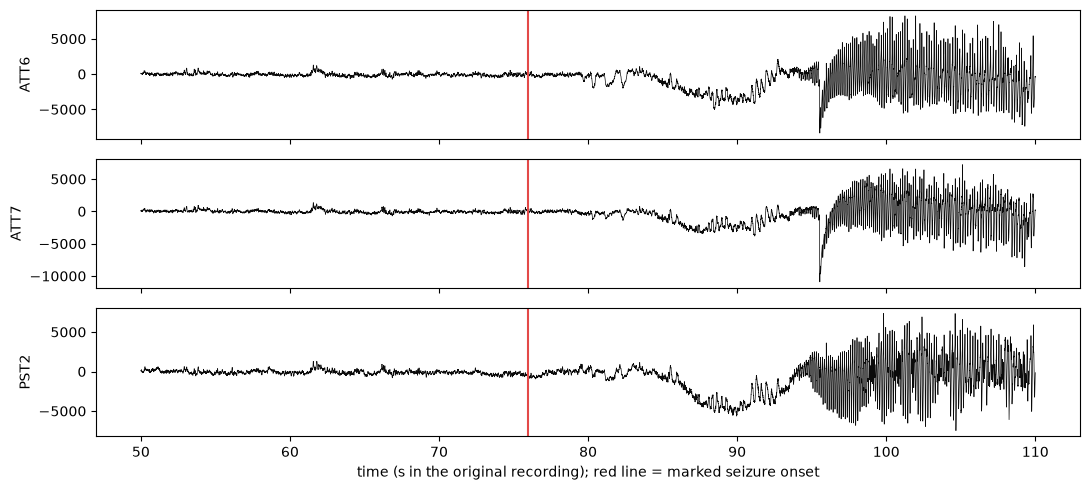

In [4]:
import matplotlib.pyplot as plt
import numpy as np

sf = recording.sfreq
data = recording.raw.get_data(picks=["ATT6", "ATT7", "PST2"]) * 1e6   # volts -> microvolts
t = recording.t_offset + np.arange(data.shape[1]) / sf

fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True)
for ax, row, name in zip(axes, data, ["ATT6", "ATT7", "PST2"], strict=False):
    ax.plot(t, row, linewidth=0.5, color="#0b0b0b")
    ax.set_ylabel(name)
    ax.axvline(recording.seizure[0], color="#e34948", linewidth=1.5)
axes[-1].set_xlabel("time (s in the original recording); red line = marked seizure onset")
fig.tight_layout()

## 3. Preprocessing

Four steps, each of which is recorded in the report so a reader knows exactly
what the detector saw:

1. keep intracranial channels, drop DC/trigger/ECG and the channels the
   dataset flagged `bad` (white matter, outside the brain, noisy);
2. high-pass at 1 Hz (drift);
3. notch at 60 Hz and harmonics — **narrow** notches, because the 180 Hz and
   240 Hz harmonics sit inside the ripple band and a wide notch would carve a
   hole in the signal we want to measure;
4. **bipolar montage**: subtract neighbouring contacts on the same electrode.
   This is standard for HFO work — a shared reference spreads its own noise
   across every channel and produces "HFOs" that appear everywhere at once.

In [5]:
from onset_hfo.preprocess import prepare

prepared = prepare(recording)
print("\nchannels:", prepared.ch_names[:8], "...", prepared.n_channels, "total")

[onset-hfo] preprocessed: 71 bipolar channels, 60.0 s @ 1000 Hz
[onset-hfo]   - kept 89 intracranial channels; dropped 9 non-brain channels (DC/trigger/ECG/misc)
[onset-hfo]   - dropped 4 channels flagged bad by the dataset: G5, G6, RQ1, RQ2
[onset-hfo]   - high-pass 1 Hz (zero-phase FIR)
[onset-hfo]   - notch 60 Hz + harmonics (60, 120, 180, 240, 300, 360, 420 Hz, 2 Hz wide)
[onset-hfo]   - bipolar montage: 71 pairs of neighbouring contacts

channels: ['AD1-AD2', 'AD2-AD3', 'AD3-AD4', 'AST1-AST2', 'AST2-AST3', 'AST3-AST4', 'ATT1-ATT2', 'ATT2-ATT3'] ... 71 total


## 4. The detectors

Two HFO detectors, deliberately simple and deliberately different:

* **RMS energy** (Staba et al., 2002) — band-pass 80–250 Hz, root-mean-square
  in a 3 ms window, threshold at 5 robust SDs of the channel's own energy,
  and then the criterion that makes it an *oscillation*: at least 6 rectified
  peaks above a secondary threshold.
* **Line length** (Gardner et al., 2007) — the same pipeline with the mean
  absolute sample-to-sample change instead of energy. It responds to fast
  low-amplitude activity that RMS misses, and to sharp edges that RMS ignores.

Plus an **interictal discharge detector**: amplitude and sharpness in the
5–60 Hz band, with an explicit check against discontinuities (an electrode pop
looks like a beautiful spike once you filter it).

Two detectors rather than one, because *a single detector cannot disagree with
anything*, and disagreement is information this prototype reports instead of
hiding.

In [6]:
from onset_hfo.pipeline import run_pipeline

result = run_pipeline(recording, save_to="artifacts/results")

[onset-hfo] preprocessed: 71 bipolar channels, 60.0 s @ 1000 Hz
[onset-hfo]   - kept 89 intracranial channels; dropped 9 non-brain channels (DC/trigger/ECG/misc)
[onset-hfo]   - dropped 4 channels flagged bad by the dataset: G5, G6, RQ1, RQ2
[onset-hfo]   - high-pass 1 Hz (zero-phase FIR)
[onset-hfo]   - notch 60 Hz + harmonics (60, 120, 180, 240, 300, 360, 420 Hz, 2 Hz wide)
[onset-hfo]   - bipolar montage: 71 pairs of neighbouring contacts


[onset-hfo] rms: 1732 candidates, 1549 accepted after artifact validation (2.3 s)


[onset-hfo] line_length: 2387 candidates, 2188 accepted after artifact validation (2.8 s)


[onset-hfo] spikes: 490 interictal discharges (1.3 s)
[onset-hfo] rate change computed: before 50-76 s vs during 76-110 s


[onset-hfo] results written to artifacts/results/sub-pt01_ictal_run-01
[onset-hfo] done in 7.5 s


Notice the two numbers printed for each detector: **candidates** and
**accepted**. Every candidate is kept in the table with the reason it was
rejected. The rejection stage is the difference between a prototype and a
demo — see section 6.

## 5. What did it find?

In [7]:
result.rates["rms"].head(8).round(2)

,channel,n_events,mean_amplitude_uv,mean_frequency_hz,mean_duration_ms,mean_prominence_db,n_with_spike,rate_per_min,rate_ci_low,rate_ci_high,duration_s
0,PST2-PST3,83,447.99,139.80,73.77,8.20,0.0,83.0,66.08,101.84,60.0
1,ATT7-ATT8,82,283.14,149.88,79.48,9.41,0.0,82.0,65.19,100.74,60.0
2,ATT6-ATT7,82,323.33,121.62,71.48,11.13,9.0,82.0,65.19,100.74,60.0
3,AST2-AST3,80,172.32,191.04,69.39,8.03,1.0,80.0,63.40,98.52,60.0
4,ATT5-ATT6,70,212.26,155.61,64.39,7.72,7.0,70.0,54.53,87.39,60.0
5,PST3-PST4,69,455.34,139.43,79.41,9.33,7.0,69.0,53.65,86.27,60.0
6,PD3-PD4,69,111.57,137.81,52.00,9.53,11.0,69.0,53.65,86.27,60.0
7,AST3-AST4,68,251.92,145.08,70.37,8.80,0.0,68.0,52.77,85.15,60.0


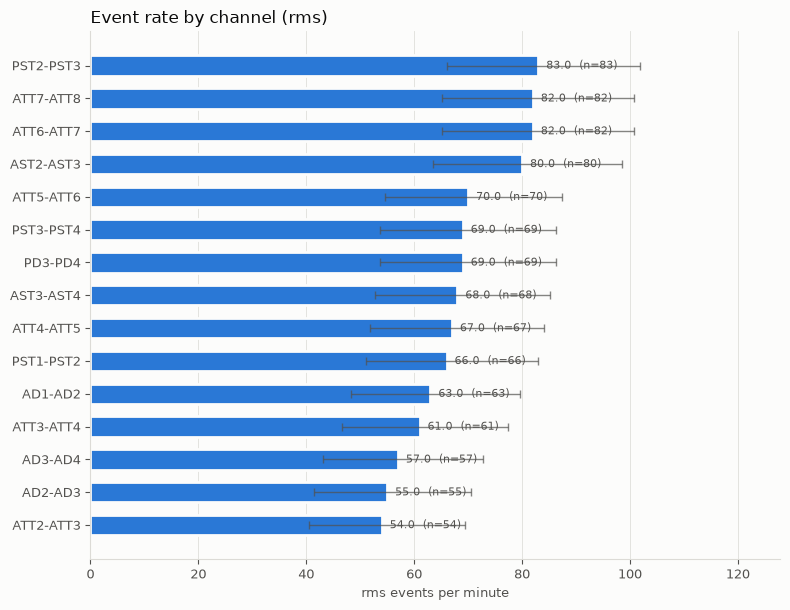

In [8]:
from onset_hfo.viz import plot_channel_rates, plot_rate_timecourse, plot_detector_comparison

fig = plot_channel_rates(result.rates["rms"], top_k=15, label="rms")

Read the confidence intervals, not just the bars. Sixty seconds of recording
turns a rate into a small count: 30 events/min *is* 30 events, and the
interval around it is wide. Two channels whose intervals overlap are not
ranked, they are tied.

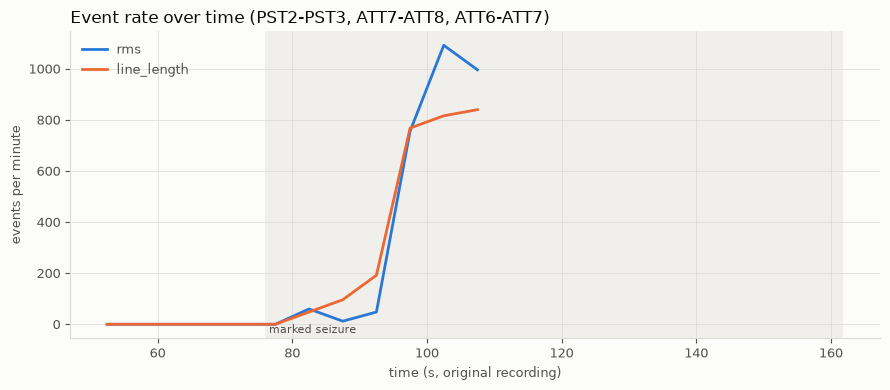

In [9]:
top = list(result.rates["rms"]["channel"].head(3))
fig = plot_rate_timecourse(result.events, prepared.t_offset,
                           prepared.t_offset + prepared.duration,
                           channels=top, seizure=recording.seizure)

The shaded region is the clinician-marked seizure. In this recording the
detected ripple rate on the leading channels is essentially zero before onset
and high during the seizure — these are *ictal* HFOs.

That is worth pausing on, because it is also a limitation: clinical HFO work
is usually done on **interictal** recordings (between seizures, often during
sleep), where a high rate is thought to mark epileptogenic tissue. This
dataset only publishes ictal snapshots, so what we measure here is "where the
seizure is loudest in the ripple band", which is a different claim.

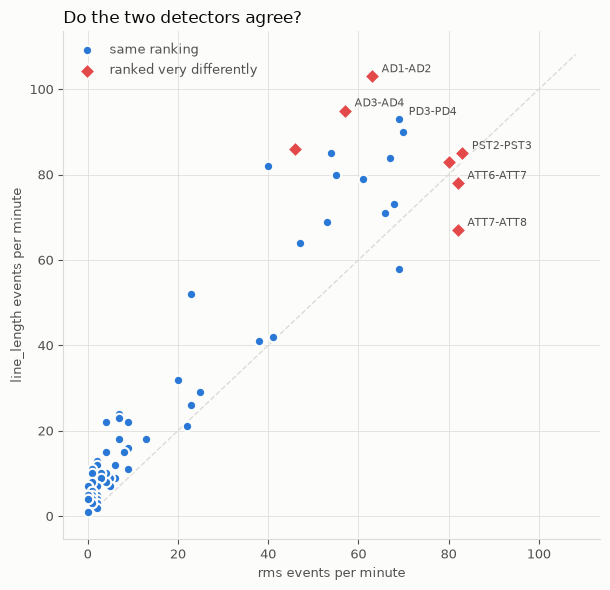

In [10]:
fig = plot_detector_comparison(result.comparison, "rms", "line_length")

In [11]:
# The channels the two detectors rank very differently, stated rather than averaged:
result.comparison[result.comparison["disagrees"]][
    ["channel", "rank_rms", "rank_line_length", "rank_gap",
     "rate_per_min_rms", "rate_per_min_line_length"]].round(1)

,channel,rank_rms,rank_line_length,rank_gap,rate_per_min_rms,rate_per_min_line_length
0,PST2-PST3,1,6,5,83.0,85.0
1,AD1-AD2,11,1,10,63.0,103.0
2,AD3-AD4,13,2,11,57.0,95.0
3,ATT6-ATT7,2,13,11,82.0,78.0
4,ATT7-ATT8,2,17,15,82.0,67.0
7,AST2-AST3,4,9,5,80.0,83.0
8,AST1-AST2,18,5,13,46.0,86.0


## 6. One event, up close

This is the figure that makes a detection arguable. Three panels: the
wideband signal, the band-passed signal, and the spectrum of the event window
against the recording's own 1/f background.

A **real oscillation** leaves a bump in the spectrum. **Filter ringing** —
what a sharp transient becomes after an 80–250 Hz filter — does not: its
spectrum is just the background pushed up. That difference is the single most
important quality check in HFO detection, and it is why the pipeline measures
*spectral prominence* for every event.

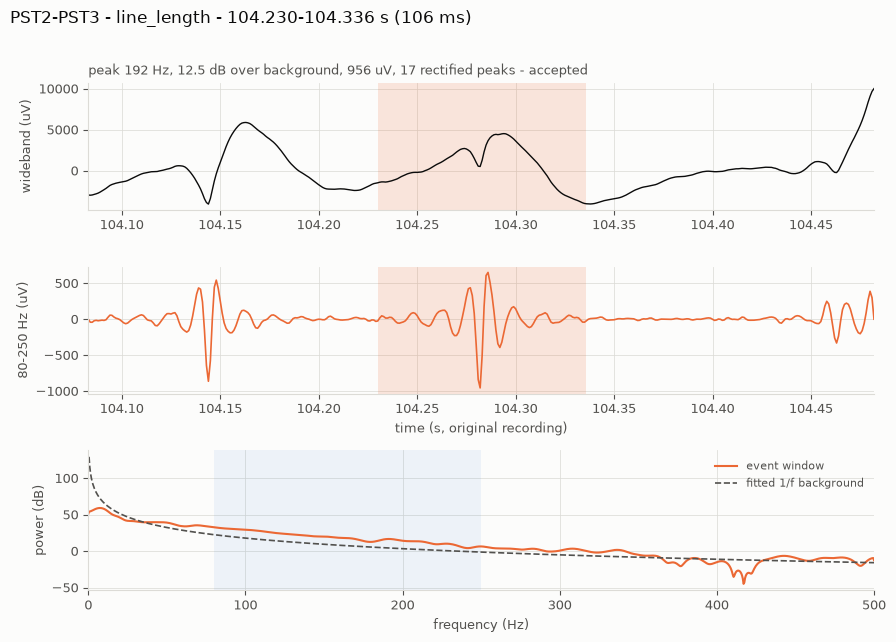

In [12]:
from onset_hfo.viz import plot_event

best = result.evidence(top[0], k=1)[0]
fig = plot_event(result.prepared, best)

in-band spectral peak only 2.7 dB above the 1/f background (< 4 dB): probable filter ringing


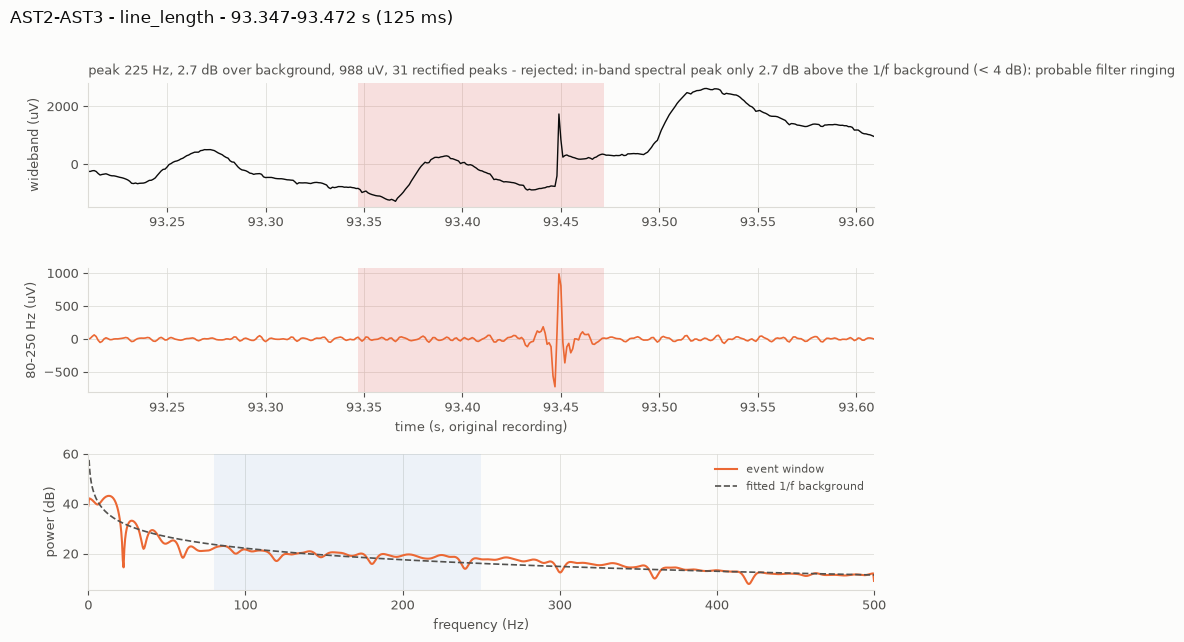

In [13]:
# ... and an event the validation stage threw away, with its reason:
rejected = sorted([e for evs in result.events.values() for e in evs if not e.accepted],
                  key=lambda e: -e.score)
print(rejected[0].reject_reason)
fig = plot_event(result.prepared, rejected[0])

## 7. The report

A structured object, not prose: findings with rates, ranks, confidence
intervals and evidence windows; disagreements between detectors stated and
left unresolved; data quality; method; limitations. There is **no
recommendation field** — not empty, absent.

In [14]:
from IPython.display import Markdown
Markdown(result.report.to_markdown())

# HFO / epileptiform evidence report -- sub-pt01 (ictal, run 01)

*Report v1, pipeline 0.1.0, generated 2026-09-20T19:59:06+00:00.*

> Decision support for research use. This report presents detector output and the
> signal windows behind it. It contains no diagnosis and no treatment recommendation.

## Summary

2 detectors ran on sub-pt01 (ictal, run 01), 60 s of recording, 98 channels. Highest event rate: ATT5-ATT6 (rms 70.0/min, line_length 90.0/min). 7 of the leading channels are ranked very differently by the two detectors. This report presents evidence windows and rates; it contains no diagnosis and no recommendation.

## Recording

- source: `openneuro:ds003029`
- 98 channels analysed, 1000.0 Hz, 50.0-110.0 s of the original recording
- clinician-marked seizure: 75.95-161.82 s

## Findings

### ATT5-ATT6
- **rms**: 70.0 events/min (95% CI 54.5-87.4, n=70), rank 5
- **line_length**: 90.0 events/min (95% CI 72.3-109.6, n=90), rank 4
- interictal discharges: 8.0/min; 9% of its HFOs coincide with one
- evidence windows: ATT5-ATT6 101.149-101.320 s [sub-pt01|ATT5-ATT6|line_length|101.149]; ATT5-ATT6 101.213-101.295 s [sub-pt01|ATT5-ATT6|rms|101.213]; ATT5-ATT6 101.918-102.034 s [sub-pt01|ATT5-ATT6|line_length|101.918]; ATT5-ATT6 101.932-102.032 s [sub-pt01|ATT5-ATT6|rms|101.932]; ATT5-ATT6 104.399-104.551 s [sub-pt01|ATT5-ATT6|line_length|104.399]; ATT5-ATT6 104.426-104.529 s [sub-pt01|ATT5-ATT6|rms|104.426]

### PD3-PD4
- **rms**: 69.0 events/min (95% CI 53.7-86.3, n=69), rank 7
- **line_length**: 93.0 events/min (95% CI 75.0-112.9, n=93), rank 3
- interictal discharges: 38.0/min; 23% of its HFOs coincide with one
- evidence windows: PD3-PD4 95.528-95.555 s [sub-pt01|PD3-PD4|rms|95.528]; PD3-PD4 95.528-95.567 s [sub-pt01|PD3-PD4|line_length|95.528]; PD3-PD4 106.889-106.959 s [sub-pt01|PD3-PD4|rms|106.889]; PD3-PD4 106.892-106.970 s [sub-pt01|PD3-PD4|line_length|106.892]; PD3-PD4 108.409-108.475 s [sub-pt01|PD3-PD4|rms|108.409]; PD3-PD4 109.703-109.797 s [sub-pt01|PD3-PD4|line_length|109.703]

## Where the detectors disagree

- **PST2-PST3** -- rms: 1, line_length: 7. the two detectors' ranks differ by 5 places; the report states both and resolves neither
  - evidence: PST2-PST3 104.230-104.336 s [sub-pt01|PST2-PST3|line_length|104.230]; PST2-PST3 104.239-104.331 s [sub-pt01|PST2-PST3|rms|104.239]
- **ATT7-ATT8** -- rms: 2, line_length: 17. the two detectors' ranks differ by 15 places; the report states both and resolves neither
  - evidence: ATT7-ATT8 100.350-100.468 s [sub-pt01|ATT7-ATT8|rms|100.350]; ATT7-ATT8 100.354-100.469 s [sub-pt01|ATT7-ATT8|line_length|100.354]
- **ATT6-ATT7** -- rms: 3, line_length: 13. the two detectors' ranks differ by 11 places; the report states both and resolves neither
  - evidence: ATT6-ATT7 100.335-100.463 s [sub-pt01|ATT6-ATT7|rms|100.335]; ATT6-ATT7 101.173-101.314 s [sub-pt01|ATT6-ATT7|rms|101.173]
- **AST2-AST3** -- rms: 4, line_length: 9. the two detectors' ranks differ by 5 places; the report states both and resolves neither
  - evidence: AST2-AST3 102.174-102.316 s [sub-pt01|AST2-AST3|line_length|102.174]; AST2-AST3 102.227-102.317 s [sub-pt01|AST2-AST3|rms|102.227]
- **AD1-AD2** -- rms: 11, line_length: 1. the two detectors' ranks differ by 10 places; the report states both and resolves neither
  - evidence: AD1-AD2 76.957-77.013 s [sub-pt01|AD1-AD2|line_length|76.957]; AD1-AD2 76.958-77.012 s [sub-pt01|AD1-AD2|rms|76.958]
- **AD3-AD4** -- rms: 13, line_length: 2. the two detectors' ranks differ by 11 places; the report states both and resolves neither
  - evidence: AD3-AD4 95.512-95.655 s [sub-pt01|AD3-AD4|line_length|95.512]; AD3-AD4 95.525-95.560 s [sub-pt01|AD3-AD4|rms|95.525]
- **AST1-AST2** -- rms: 18, line_length: 5. the two detectors' ranks differ by 13 places; the report states both and resolves neither
  - evidence: AST1-AST2 96.766-96.848 s [sub-pt01|AST1-AST2|line_length|96.766]; AST1-AST2 98.677-98.792 s [sub-pt01|AST1-AST2|rms|98.677]

## Rate before and during the marked seizure

| channel | before (/min) | during (/min) | ratio |
|---|---|---|---|
| PST2-PST3 | 0.0 | 146.3 | n/a |
| ATT7-ATT8 | 0.0 | 144.5 | n/a |
| ATT6-ATT7 | 0.0 | 144.5 | n/a |
| AST2-AST3 | 0.0 | 141.0 | n/a |
| ATT5-ATT6 | 0.0 | 123.3 | n/a |

## Data quality

- slice 50-110 s of the original recording; all times reported by this pipeline are in original-recording seconds
- 11 channels flagged bad in channels.tsv (white matter, CSF, outside brain, or noisy) and excluded
- rms: 1732 candidate events, 183 rejected by artifact validation (in-band spectral peak only 3.7 dB above the 1/f background (< 4 dB): 13, in-band spectral peak only 3.6 dB above the 1/f background (< 4 dB): 11, in-band spectral peak only 3.2 dB above the 1/f background (< 4 dB): 10, in-band spectral peak only 3.5 dB above the 1/f background (< 4 dB): 10, in-band spectral peak only 3.8 dB above the 1/f background (< 4 dB): 7, in-band spectral peak only 3.3 dB above the 1/f background (< 4 dB): 7, in-band spectral peak only 2.4 dB above the 1/f background (< 4 dB): 7, in-band spectral peak only 3.0 dB above the 1/f background (< 4 dB): 7, in-band spectral peak only 3.4 dB above the 1/f background (< 4 dB): 7, in-band spectral peak only 3.9 dB above the 1/f background (< 4 dB): 7, in-band spectral peak only 1.3 dB above the 1/f background (< 4 dB): 6, in-band spectral peak only 2.9 dB above the 1/f background (< 4 dB): 5, in-band spectral peak only 3.1 dB above the 1/f background (< 4 dB): 5, in-band spectral peak only 2.2 dB above the 1/f background (< 4 dB): 5, in-band spectral peak only 2.6 dB above the 1/f background (< 4 dB): 4, in-band spectral peak only 0.3 dB above the 1/f background (< 4 dB): 4, in-band spectral peak only 0.2 dB above the 1/f background (< 4 dB): 4, in-band spectral peak only 1.4 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only 2.3 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only -0.8 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only 2.8 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only 1.7 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only 1.9 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only 2.7 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only 1.0 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 0.4 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only -0.5 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 0.9 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 0.6 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 0.5 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only -0.7 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 1.8 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 2.1 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 1.6 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 2.5 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 1.2 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 1.1 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 1.5 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 4.0 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 2.0 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only -1.9 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -0.3 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -1.6 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -0.6 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -1.0 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -2.4 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only 0.8 dB above the 1/f background (< 4 dB): 1, only 1.9 cycles (< 2): 1, only 2.0 cycles (< 2): 1, in-band spectral peak only -0.4 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -0.2 dB above the 1/f background (< 4 dB): 1)
- line_length: 2387 candidate events, 199 rejected by artifact validation (in-band spectral peak only 3.9 dB above the 1/f background (< 4 dB): 12, in-band spectral peak only 3.5 dB above the 1/f background (< 4 dB): 11, in-band spectral peak only 3.8 dB above the 1/f background (< 4 dB): 10, in-band spectral peak only 3.3 dB above the 1/f background (< 4 dB): 10, in-band spectral peak only 3.0 dB above the 1/f background (< 4 dB): 10, in-band spectral peak only 3.4 dB above the 1/f background (< 4 dB): 9, in-band spectral peak only 3.6 dB above the 1/f background (< 4 dB): 9, in-band spectral peak only 3.2 dB above the 1/f background (< 4 dB): 8, in-band spectral peak only 2.7 dB above the 1/f background (< 4 dB): 7, in-band spectral peak only 2.0 dB above the 1/f background (< 4 dB): 7, in-band spectral peak only 2.8 dB above the 1/f background (< 4 dB): 6, in-band spectral peak only 2.9 dB above the 1/f background (< 4 dB): 6, in-band spectral peak only 2.1 dB above the 1/f background (< 4 dB): 6, in-band spectral peak only 1.5 dB above the 1/f background (< 4 dB): 5, in-band spectral peak only 4.0 dB above the 1/f background (< 4 dB): 5, in-band spectral peak only 3.7 dB above the 1/f background (< 4 dB): 5, in-band spectral peak only 2.4 dB above the 1/f background (< 4 dB): 5, in-band spectral peak only 1.8 dB above the 1/f background (< 4 dB): 4, in-band spectral peak only 1.2 dB above the 1/f background (< 4 dB): 4, in-band spectral peak only 1.3 dB above the 1/f background (< 4 dB): 4, in-band spectral peak only 2.6 dB above the 1/f background (< 4 dB): 4, in-band spectral peak only 3.1 dB above the 1/f background (< 4 dB): 4, in-band spectral peak only 0.6 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only 2.3 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only 1.6 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only 1.7 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only 1.4 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only 0.4 dB above the 1/f background (< 4 dB): 3, in-band spectral peak only -0.8 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 0.8 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only -0.6 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 1.9 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 0.5 dB above the 1/f background (< 4 dB): 2, only 1.9 cycles (< 2): 2, in-band spectral peak only 0.3 dB above the 1/f background (< 4 dB): 2, in-band spectral peak only 1.0 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -0.1 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -1.9 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -0.4 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -1.3 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -1.1 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only 0.9 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -1.0 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -0.3 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only 0.7 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -0.2 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -2.3 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only 1.1 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -0.5 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -1.5 dB above the 1/f background (< 4 dB): 1, in-band spectral peak only -1.6 dB above the 1/f background (< 4 dB): 1)
- rates are events per minute over the analysed window; confidence intervals assume a Poisson process

## Method

- kept 89 intracranial channels; dropped 9 non-brain channels (DC/trigger/ECG/misc)
- dropped 4 channels flagged bad by the dataset: G5, G6, RQ1, RQ2
- high-pass 1 Hz (zero-phase FIR)
- notch 60 Hz + harmonics (60, 120, 180, 240, 300, 360, 420 Hz, 2 Hz wide)
- bipolar montage: 71 pairs of neighbouring contacts
- detectors: rms, line_length (see docs/METHODS.md)
- configuration: {"preprocess": {"line_freq": 60.0, "notch": true, "bipolar": true, "highpass": 1.0, "drop_bads": true}, "rms": {"band": [80.0, 250.0], "rms_window_ms": 3.0, "threshold_sd": 5.0, "extend_sd": 2.0, "peak_threshold_sd": 2.0, "min_peaks": 6, "min_duration_ms": 6.0, "max_duration_ms": 200.0, "merge_gap_ms": 10.0, "baseline": "robust"}, "line_length": {"band": [80.0, 250.0], "rms_window_ms": 3.0, "threshold_sd": 3.0, "extend_sd": 2.0, "peak_threshold_sd": 2.0, "min_peaks": 6, "min_duration_ms": 6.0, "max_duration_ms": 200.0, "merge_gap_ms": 10.0, "baseline": "robust"}, "spikes": {"band": [5.0, 60.0], "threshold_sd": 6.0, "slope_sd": 5.0, "min_duration_ms": 10.0, "max_duration_ms": 200.0, "refractory_ms": 200.0, "max_raw_jump_sd": 10.0}, "validation": {"min_peak_prominence_db": 4.0, "max_low_band_sd": 8.0, "min_cycles": 2.0}, "rate_window_s": 60.0, "top_k": 5, "disagreement_ranks": 5}

## Limitations

- prototype: thresholds were chosen from the literature and checked on synthetic data, not tuned or validated on a labelled clinical cohort
- no HFO ground truth exists for this public recording, so precision and recall are not reported here; they are measured on synthetic data in docs/EVALUATION.md
- event rate is not a diagnosis: physiological ripples occur in healthy tissue, particularly in mesial temporal and occipital regions
- a single short window of a single patient; nothing here generalises
- bipolar pairs are formed from consecutive contact numbers, which on a grid is not always spatial adjacency

## Data citation

Li A, Inati S, Zaghloul K, Crone N, Anderson W, Johnson E, Cajigas I, Brusko D, Jagid J, Claudio A, Kanner A, Hopp J, Chen S, Haagensen J, Sarma S. Epilepsy-iEEG-Multicenter-Dataset. OpenNeuro (2021). doi:10.18112/openneuro.ds003029.v1.0.3 -- the archive asks that work using it also cite 'Neural fragility as an EEG marker of the seizure onset zone', doi:10.1101/862797 (Nature Neuroscience, 2023).


## 8. A weak reality check

We have no HFO ground truth for this recording. What we do have is the list of
contacts the clinician named in the seizure markers. Are our top-ranked
channels drawn from them more often than chance?

The honest way to ask is a permutation test, and the honest way to read the
answer is with both hands: the markers are not an SOZ label, they are
incomplete, and this is a 60-second ictal window.

In [15]:
from onset_hfo.evaluate import marked_contact_check

check = marked_contact_check(result.rates["rms"], recording.marked_contacts, k=10)
print(json.dumps(check, indent=2))

{
  "available": true,
  "k": 10,
  "marked_contacts": [
    "AD1",
    "AD2",
    "AD3",
    "AD4",
    "AST1",
    "AST3",
    "ATT1",
    "ATT2",
    "G16",
    "G8",
    "SLT1",
    "SLT2",
    "SLT3"
  ],
  "top_channels": [
    "PST2-PST3",
    "ATT7-ATT8",
    "ATT6-ATT7",
    "AST2-AST3",
    "ATT5-ATT6",
    "PST3-PST4",
    "PD3-PD4",
    "AST3-AST4",
    "ATT4-ATT5",
    "PST1-PST2"
  ],
  "n_top_touching_marked": 2,
  "expected_by_chance": 2.148,
  "permutation_p_value": 0.6771614192903548,
  "interpretation": "the clinician's free-text markers are not a curated seizure-onset zone; treat agreement as mild encouragement and disagreement as uninformative"
}


Whatever this prints, do not over-read it. If the overlap is no better than
chance that is unsurprising for ictal data and a rate-only ranking; if it is
better, it is mild encouragement and nothing more. Precision and recall are
measured in notebook 3, on synthetic data where the truth is known.

## 9. Where the results went

Everything is saved as CSV and JSON. That directory is also the *only* thing
the agent in notebook 2 can read.

In [16]:
import os
out = "artifacts/results/sub-pt01_ictal_run-01"
print("\n".join(sorted(os.listdir(out))))

agreement.json
comparison.csv
config.json
events.csv
figures
provenance.json
rate_change.csv
rates_line_length.csv
rates_rms.csv
rates_spike.csv
report.json
report.md


## What to try next

* Change the window (`t_start` / `t_stop`) to a purely pre-ictal stretch and
  see whether the ranking changes. If a channel's rank depends on which minute
  you picked, that is worth knowing before anyone builds on it.
* Raise `threshold_sd` from 5 to 7 in `PipelineConfig` and watch the rates
  fall. Which channels survive?
* Run another subject (`list_runs("sub-jh103")`) and compare.
* Open **notebook 2** to ask an open-weight language model about these
  results, and **notebook 3** to measure how good the detectors actually are.

**Reading**: `docs/METHODS.md` (the algorithms and their references),
`docs/DATA.md` (what is and is not in this dataset), `docs/LIMITATIONS.md`
(what this prototype must not be used for).